In [1]:
from resources.imports import *
from resources.MLdata import DATA

import glob
from scipy.interpolate import griddata
from scipy.spatial import Delaunay
import networkx as nx
from scipy.spatial.distance import cdist
from matplotlib.collections import LineCollection
import matplotlib.colors as colors
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.patheffects as pe

In [2]:
DAT = DATA(path=1, 
        path_add="",
        LAT="FCC", 
        dis="disNodes", 
        dN=0.2,
        mechMode="UT")

os.chdir(f'{DAT.PATH}sims')

frame = 9
MAX = "maxD"
if DAT.path_add == "Target-xs":
    target = "xs"
else:
    target = "all"

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:672: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


In [3]:
def find_6_neighbor_connectivity(A1, A2, l, tolerance=1e-4):
    """
    Identifies nodes in A1 that are NOT in A2, but have exactly 6 neighbors 
    in A2 at distance 'l'.
    
    Returns:
    - connectivity_list: (N, 2) array. 
         Column 0: Index relative to the NEW reduced list (final_A1_coords).
         Column 1: Index relative to A2.
    - final_A1_coords: (M, 2) array of the (x,y) coordinates of the valid A1 nodes.
    """
    
    # 1. Calculate Distance Matrix
    # Shape: (Num_A1, Num_A2)
    D = cdist(A1, A2)
    
    # 2. Identify Non-Shared Nodes
    is_not_shared = D.min(axis=1) > tolerance
    
    # 3. Identify Neighbors at distance 'l'
    is_neighbor = np.abs(D - l) < tolerance
    
    # 4. Count Neighbors
    neighbor_counts = is_neighbor.sum(axis=1)
    
    # 5. Filter: Must be Not Shared AND have exactly 6 Neighbors
    valid_nodes_mask = is_not_shared & (neighbor_counts == 6)
    
    # Create the reduced coordinate list
    final_A1_coords = A1[valid_nodes_mask]
    
    # 6. Generate the Connectivity List
    # We slice the boolean neighbor matrix to include ONLY the valid rows.
    # This means row 0 of this new matrix corresponds to entry 0 of final_A1_coords.
    valid_neighbor_matrix = is_neighbor[valid_nodes_mask, :]
    
    # Find indices (r, c)
    # r: Row index in valid_neighbor_matrix (0 to M-1) -> Index in Reduced List
    # c: Column index -> Index in A2
    r, c = np.where(valid_neighbor_matrix)
    
    connectivity_list = np.column_stack((r, c))
    
    return connectivity_list, final_A1_coords

def calculate_green_lagrange_strain(initial_triangle_coords, final_triangle_coords, strain_type='von_mises'):
    P1 = initial_triangle_coords[0, :]
    P2 = initial_triangle_coords[1, :]
    P3 = initial_triangle_coords[2, :]
    p1 = final_triangle_coords[0, :]
    p2 = final_triangle_coords[1, :]
    p3 = final_triangle_coords[2, :]
    dX = np.array([P2 - P1, P3 - P1]).T
    dx = np.array([p2 - p1, p3 - p1]).T

    F = dx @ np.linalg.inv(dX)
    I = np.eye(2)
    E_tensor = 0.5 * (F.T @ F - I)
    E_xx = E_tensor[0, 0]
    E_yy = E_tensor[1, 1]
    E_xy = E_tensor[0, 1]

    if strain_type == 'max_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.max(eigenvalues)
    elif strain_type == 'min_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.min(eigenvalues)
    elif strain_type == 'von_mises':
        e1, e2 = np.linalg.eigvalsh(E_tensor)
        return np.sqrt(e1**2 + e2**2 - e1*e2)
    elif strain_type == 'E_xx':
        return E_xx
    elif strain_type == 'E_yy':
        return E_yy
    elif strain_type == 'E_xy':
        return E_xy

In [4]:
perSimDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-per-1')[0]
if MAX == "per":
    simDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-per-1')[0]
else:
    simDir = glob.glob(f'{DAT.mechTest}-{DAT.LAT}-{DAT.nnx}-{int(DAT.dN*100)}{DAT.dis}-lhs-{target}-*-{MAX}')[0]

dispsCSV = f'{simDir}/frame{frame}.csv'
NodesElemsCSV = f'{simDir}/NodesElems.csv'
perNodesElemsCSV = f'{perSimDir}/NodesElems.csv'

with open(NodesElemsCSV) as f:
    lines = f.readlines()
with open(perNodesElemsCSV) as f:
    perLines = f.readlines()

nodesStart = lines.index([line for line in lines if "*Nodes" in line][0])+1
elemsStart = perLines.index([line for line in lines if "*Elems" in line][0])+1

disps = pd.read_csv(dispsCSV).to_numpy()[:, 1:]
nodes = pd.read_csv(NodesElemsCSV, names=['node', 'x', 'y'], skiprows=nodesStart, nrows=elemsStart-2).to_numpy()[:, 1:]
perNodes = pd.read_csv(perNodesElemsCSV, names=['node', 'x', 'y'], skiprows=nodesStart, nrows=elemsStart-2).to_numpy()[:, 1:]
elems = pd.read_csv(perNodesElemsCSV, names=['elem', 'n1', 'n2'], skiprows=elemsStart).to_numpy()[:, 1:]
elems = elems-1

if DAT.LAT.lower() in ["hex", "kagome"]:
    x_min, x_max = perNodes[:,0].min(), perNodes[:,0].max()
    y_min, y_max = perNodes[:,1].min(), perNodes[:,1].max()

    all_pts = []
    if DAT.LAT == "hex":
        x_start1 = x_min
        y_start1 = y_min + DAT.geom.l/2

        x_start2 = x_min + (DAT.geom.l * (np.sqrt(3)/2))
        y_start2 = y_min

        for y in np.arange(y_start1, y_max, DAT.geom.l):
            for x in np.arange(x_start1, x_max, DAT.geom.l*np.sqrt(3)):
                all_pts.append((x, y))
        for y in np.arange(y_start2, y_max, DAT.geom.l):
            for x in np.arange(x_start2, x_max, DAT.geom.l*np.sqrt(3)):
                all_pts.append((x, y))

    elif DAT.LAT == "kagome":
        x_start = x_min + (DAT.geom.l/2)
        y_start = y_min + (DAT.geom.l * (np.sqrt(3)/2))

        for y in np.arange(y_start, y_max, DAT.geom.l*np.sqrt(3)):
            for x in np.arange(x_start, x_max, DAT.geom.l):
                all_pts.append((x, y))

    all_pts = np.array(all_pts)

    matches = (np.round(all_pts, decimals=2)[:, None, :] == np.round(perNodes, decimals=2)[None, :, :]).all(axis=-1)
    is_shared = matches.any(axis=1)
    non_shared_indices = np.where(~is_shared)[0]
    all_pts = all_pts[non_shared_indices]

    links, valid_nodes = find_6_neighbor_connectivity(all_pts, perNodes, l=DAT.geom.l)
    all_pts = valid_nodes

    new_nodes = np.zeros((len(all_pts), 2))
    for i in list(set(links[:,0])):
        new_nodes[i,0] = nodes[links[links[:,0]==i][:,1],0].mean()
        new_nodes[i,1] = nodes[links[links[:,0]==i][:,1],1].mean()

    new_disps = np.zeros((len(all_pts), 2))
    for i in list(set(links[:,0])):
        new_disps[i,0] = disps[links[links[:,0]==i][:,1],0].mean()
        new_disps[i,1] = disps[links[links[:,0]==i][:,1],1].mean()

    vNodes_start = len(perNodes)
    links[:,0] += vNodes_start

    new_perNodes = np.vstack((perNodes, all_pts))
    new_nodes = np.vstack((nodes, new_nodes))
    new_disps = np.vstack((disps, new_disps))
    new_elems = np.vstack((elems, links))
else:
    new_perNodes = perNodes
    new_nodes = nodes
    new_disps = disps
    new_elems = elems

if DAT.mechMode == "FT":
    dElems = []
    count = 0
    for elem in elems:
        n1 = elem[0]
        n2 = elem[1]
        x1, y1 = nodes[n1]
        x2, y2 = nodes[n2]
        mid = ((x1+x2)/2, (y1+y2)/2)
        if mid[0] < DAT.geom.a0 - DAT.geom.l/4:
            if (mid[1] > DAT.geom.H/2 - DAT.geom.l/4) and (mid[1] < DAT.geom.H/2 + DAT.geom.l/4):
                dElems.append(count)
        count += 1
    elems = np.delete(elems, dElems, axis=0)

    if DAT.LAT.lower() in ["hex", "kagome"]:
        dElems, dNodes = [], []
        count = 0
        for elem in new_elems:
            n1 = elem[0]
            n2 = elem[1]
            x1, y1 = new_nodes[n1]
            x2, y2 = new_nodes[n2]
            mid = ((x1+x2)/2, (y1+y2)/2)
            if mid[0] < DAT.geom.a0 - DAT.geom.l/4:
                if (mid[1] > DAT.geom.H/2 - DAT.geom.l/1.5) and (mid[1] < DAT.geom.H/2 + DAT.geom.l/1.5):
                    dElems.append(count)
            count += 1
        count = 0
        for node in new_nodes:
            if node[0] < DAT.geom.a0 - DAT.geom.l/4:
                if (node[1] > DAT.geom.H/2 - DAT.geom.l/4) and (node[1] < DAT.geom.H/2 + DAT.geom.l/4):
                    dNodes.append(count)
            count += 1
        new_elems = np.delete(new_elems, dElems, axis=0)
        # new_nodes = np.delete(new_nodes, dNodes, axis=0)
        # new_disps = np.delete(new_disps, dNodes, axis=0)

In [5]:
# plt.figure(figsize=(10, 10))
# for elem in elems:
#     n1 = elem[0]
#     n2 = elem[1]
#     plt.plot([nodes[n1][0]+disps[n1][0], nodes[n2][0]+disps[n2][0]], [nodes[n1][1]+disps[n1][1], nodes[n2][1]+disps[n1][1]], 'k')

# plt.figure(figsize=(10, 10))
# for elem in elems:
#     n1 = elem[0]
#     n2 = elem[1]
#     plt.plot([nodes[n1][0], nodes[n2][0]], [nodes[n1][1], nodes[n2][1]], 'k')

# plt.figure(figsize=(10, 10))
# for elem in new_elems:
#     n1 = elem[0]
#     n2 = elem[1]
#     plt.plot([new_nodes[n1][0]+new_disps[n1][0], new_nodes[n2][0]+new_disps[n2][0]], [new_nodes[n1][1]+new_disps[n1][1], new_nodes[n2][1]+new_disps[n2][1]], 'k')
# plt.scatter(new_nodes[:,0], new_nodes[:,1], c='gray', s=1)

Found 2064 physical triangles (3-cliques).
Calculated strains for 2064 triangles.
Strain range: min=-0.0193, max=0.3374


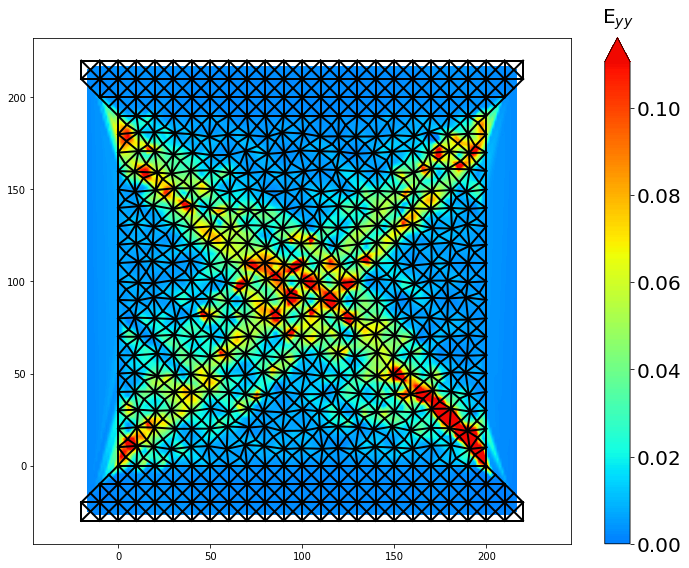

In [6]:
initial_coords = np.asarray(new_nodes)
displacements = np.asarray(new_disps) 
edge_node_pairs = np.asarray(new_elems) 

final_coords = initial_coords + displacements
num_total_nodes = initial_coords.shape[0]

# --- Element Definition for Strain Calculation ---
G = nx.Graph()
G.add_edges_from(edge_node_pairs)

all_triangles_for_strain_set = set()
if G.number_of_nodes() > 0:
    for clique in nx.find_cliques(G): # find_cliques works for undirected
        if len(clique) == 3:
            all_triangles_for_strain_set.add(tuple(sorted(clique)))
print(f"Found {len(all_triangles_for_strain_set)} physical triangles (3-cliques).")

triangles_node_indices = np.array(list(all_triangles_for_strain_set), dtype=int)

# --- Strain Calculation ---
if DAT.mechMode == "UT":
    strain_measure_to_plot = 'E_yy'
elif DAT.mechMode == "FT":
    strain_measure_to_plot = 'E_yy'

element_strains = []
element_centroids_initial = []

if triangles_node_indices.shape[0] > 0:
    for i, tri_indices in enumerate(triangles_node_indices):
        if len(tri_indices) != 3: continue
        initial_triangle_nodes = initial_coords[tri_indices]
        final_triangle_nodes = final_coords[tri_indices]
        strain = calculate_green_lagrange_strain(initial_triangle_nodes, final_triangle_nodes, strain_type=strain_measure_to_plot)
        if not np.isnan(strain):
            element_strains.append(strain)
            element_centroids_initial.append(np.mean(initial_triangle_nodes, axis=0))
else:
    print("Skipping strain calculation as no triangles are defined.")

element_strains = np.array(element_strains)
element_centroids_initial = np.array(element_centroids_initial)

if element_strains.size == 0:
    print("Warning: No valid strains calculated. Plot will be empty or show errors.")

# --- Plotting (imshow) ---
print(f"Calculated strains for {len(element_strains)} triangles.")
if element_strains.size > 0:
    print(f"Strain range: min={np.nanmin(element_strains):.4f}, max={np.nanmax(element_strains):.4f}")
else:
    print("Strain range: N/A (no strains calculated)")


pad_factor = 0.05
if initial_coords.shape[0] > 0:
    x_min_overall, y_min_overall = np.min(initial_coords, axis=0)
    x_max_overall, y_max_overall = np.max(initial_coords, axis=0)
else:
    x_min_overall, y_min_overall = -1, -1
    x_max_overall, y_max_overall = 1, 1

x_range = x_max_overall - x_min_overall
y_range = y_max_overall - y_min_overall
if x_range <= 0: x_range = 1.0
if y_range <= 0: y_range = 1.0

grid_x_coords = np.linspace(x_min_overall - pad_factor * x_range, x_max_overall + pad_factor * x_range, 200)
grid_y_coords = np.linspace(y_min_overall - pad_factor * y_range, y_max_overall + pad_factor * y_range, 200)
GX, GY = np.meshgrid(grid_x_coords, grid_y_coords)

strain_grid = np.full(GX.shape, np.nan)

if element_centroids_initial.shape[0] > 0 and element_strains.shape[0] > 0:
    strain_grid_temp = griddata(element_centroids_initial, element_strains, (GX, GY), method='linear')
    if strain_grid_temp is not None:
        strain_grid = strain_grid_temp

    if element_centroids_initial.shape[0] >= 3:
        tri_centroids = Delaunay(element_centroids_initial)
        grid_points_flat = np.vstack((GX.ravel(), GY.ravel())).T
        simplex_indices = tri_centroids.find_simplex(grid_points_flat)
        mask = simplex_indices != -1
        mask = mask.reshape(GX.shape)
        strain_grid[~mask] = np.nan
    else:
        print("Warning: Not enough centroids for Delaunay masking.")
else:
    print("Skipping griddata and masking as there are no element centroids/strains.")


fig, ax = plt.subplots(figsize=(10, 8))

s_min = 0.0     # np.nanmin(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)
s_max = 0.1105  # np.nanmax(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)

cmap_imshow = plt.get_cmap('jet')
vmin, vmax = 0.25, 0.9
subset_colors = cmap_imshow(np.linspace(vmin, vmax, 256))
cmap_imshow = colors.LinearSegmentedColormap.from_list('bright_jet', subset_colors)
im = ax.imshow(strain_grid, extent=(grid_x_coords[0], grid_x_coords[-1], grid_y_coords[0], grid_y_coords[-1]),
               origin='lower', cmap=cmap_imshow, aspect='auto',
               vmin=s_min, vmax=s_max, interpolation='bilinear')

for n1_idx, n2_idx in elems:
    ax.plot([nodes[n1_idx,0], nodes[n2_idx,0]],
            [nodes[n1_idx,1], nodes[n2_idx,1]], 'k', lw=2)
            # path_effects=[pe.withStroke(linewidth=1.5, foreground="lightgray")])


cbar = plt.colorbar(im, extend="max")
cbar.ax.set_title('E$_{yy}$', fontsize=20, pad=15)
cbar.ax.tick_params(labelsize=20)
plt.axis('equal')
if DAT.mechMode == "FT":
    if DAT.LAT in ["hex", "kagome"]:
        ax.set_ylim(DAT.geom.H/2 - 10*DAT.geom.l, DAT.geom.H/2 + 10*DAT.geom.l)
        ax.set_xlim(DAT.geom.a0 - 10*DAT.geom.l, DAT.geom.a0 + 10*DAT.geom.l)
    else:
        ax.set_ylim(DAT.geom.H/2 - 6*DAT.geom.l, DAT.geom.H/2 + 6*DAT.geom.l)
        ax.set_xlim(DAT.geom.a0 - 6*DAT.geom.l, DAT.geom.a0 + 6*DAT.geom.l)
plt.tight_layout()
plt.show()

Computed LE strains for 3149 elements.
Strain Range: Min=-0.1990, Max=0.1887


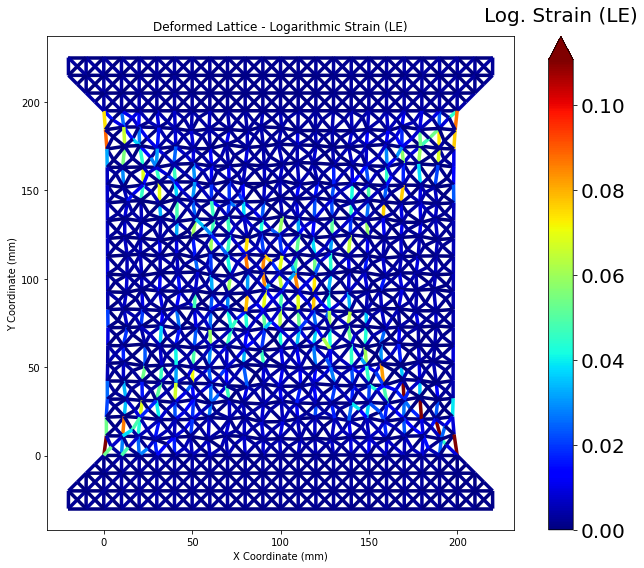

In [7]:
def plot_displaced_lattice_strain(nodes, elems, disps, 
                                  line_width=1.5, 
                                  color_limits=(0.0, 0.1105),
                                  cmap_name='jet'):
    """
    Plots the displaced lattice with element colors corresponding to 
    Logarithmic Strain (LE = ln(L/L0)).
    
    Parameters:
    - nodes: (N, 2) array of initial coordinates.
    - elems: (M, 2) array of node indices for each element.
    - disps: (N, 2) array of displacements (u, v).
    - line_width: float, thickness of the lines.
    - color_limits: tuple (min, max) for the colorbar range.
    - cmap_name: string, matplotlib colormap name.
    """
    
    # Ensure indices are integers
    elems = elems.astype(int)

    # --- 1. Calculate Logarithmic Strain (LE) ---
    # Get coordinates of start (1) and end (2) nodes for all elements
    p1_initial = nodes[elems[:, 0]]
    p2_initial = nodes[elems[:, 1]]
    
    p1_final = p1_initial + disps[elems[:, 0]]
    p2_final = p2_initial + disps[elems[:, 1]]

    # Vectorized length calculations
    L0 = np.linalg.norm(p2_initial - p1_initial, axis=1) # Initial lengths
    L_curr = np.linalg.norm(p2_final - p1_final, axis=1) # Deformed lengths

    # Avoid division by zero warnings if L0 is 0 (though unlikely in lattice)
    with np.errstate(divide='ignore', invalid='ignore'):
        le_strains = np.log(L_curr / L0)
    
    # Handle any potential NaNs (e.g., zero length elements)
    le_strains = np.nan_to_num(le_strains)

    print(f"Computed LE strains for {len(le_strains)} elements.")
    print(f"Strain Range: Min={le_strains.min():.4f}, Max={le_strains.max():.4f}")

    # --- 2. Prepare Plotting Data ---
    # Create segments array for LineCollection: Shape (Num_Elems, 2_points, 2_coords)
    segments = np.stack((p1_final, p2_final), axis=1)

    # Setup Figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create Norm and Colormap
    vmin, vmax = color_limits
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    # Create Line Collection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=line_width)
    lc.set_array(le_strains) # Map strain values to colors
    ax.add_collection(lc)

    # --- 3. Formatting & Legend ---
    # Auto-scale view to fit the displaced lattice
    all_x = np.concatenate((p1_final[:,0], p2_final[:,0]))
    all_y = np.concatenate((p1_final[:,1], p2_final[:,1]))
    
    # Add a small buffer to the view
    buffer = 0.05 * (all_x.max() - all_x.min())
    ax.set_xlim(all_x.min() - buffer, all_x.max() + buffer)
    ax.set_ylim(all_y.min() - buffer, all_y.max() + buffer)
    ax.set_aspect('equal')
    ax.set_xlabel('X Coordinate (mm)')
    ax.set_ylabel('Y Coordinate (mm)')
    ax.set_title('Deformed Lattice - Logarithmic Strain (LE)')

    # Add Colorbar with specific requests (Title top, Size 20, Extend max)
    cbar = plt.colorbar(lc, ax=ax, extend='max')
    
    # Set title at the top
    cbar.ax.set_title('Log. Strain (LE)', fontsize=20, pad=15)
    
    # Set tick labels font size
    cbar.ax.tick_params(labelsize=20)

    if DAT.mechMode == "FT":
        if DAT.LAT == "kagome":
            ax.set_ylim(DAT.geom.H/2 - 7*DAT.geom.l, DAT.geom.H/2 + 7*DAT.geom.l)
            ax.set_xlim(DAT.geom.a0 - 7*DAT.geom.l, DAT.geom.a0 + 7*DAT.geom.l)
        elif DAT.LAT == "hex":
            ax.set_ylim(DAT.geom.H/2 - 5*DAT.geom.l, DAT.geom.H/2 + 8*DAT.geom.l)
            ax.set_xlim(DAT.geom.a0 - 8*DAT.geom.l, DAT.geom.a0 + 7*DAT.geom.l)
        else:
            ax.set_ylim(DAT.geom.H/2 - 4*DAT.geom.l, DAT.geom.H/2 + 4*DAT.geom.l)
            ax.set_xlim(DAT.geom.a0 - 4*DAT.geom.l, DAT.geom.a0 + 4*DAT.geom.l)
    plt.tight_layout()
    plt.show()

# --- Example Usage with your data ---
# Assuming 'nodes', 'elems', and 'disps' are already loaded from your script above:

plot_displaced_lattice_strain(
    nodes, 
    elems, 
    disps, 
    line_width=3.5,            # Change thickness here
    color_limits=(0.0, 0.1105) # Change legend range here
)